### TP INF 372 : Analyse de la Consommation Data

| Nom Complet | Matricule |
| :--- | :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN | 23U2477 |

---

# Prédiction de la période de la journée à partir de la consommation réseau

## Objectif
L'objectif de ce projet est de développer un modèle d'apprentissage supervisé (classification multi-classes) capable de prédire la période de la journée (Matin, Après-midi, Soir, Nuit) d'une session internet.

**La contrainte majeure et la valeur ajoutée de cette étude** : L'aveuglement temporel. Aucune information temporelle directe (comme l'heure exacte) ne doit être fournie au modèle. Le défi est donc d'inférer une variable de temps exclusivement à partir de la signature comportementale et volumétrique du trafic réseau de l'utilisateur.

## Approche
- Prétraitement des données
- Feature engineering
- Modélisation avec KNN
- Optimisation des hyperparamètres
- Analyse des performances

In [ ]:
!pip install pandas numpy matplotlib scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance

In [4]:
df = pd.read_csv('dataset_classification.csv')
df.head()
df.info()
df.describe()
df['periode_journee'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58898 entries, 0 to 58897
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   heure             58898 non-null  int64  
 1   periode_journee   58898 non-null  object 
 2   statut_connexion  58401 non-null  float64
 3   download_Mo       58897 non-null  float64
 4   upload_Mo         58897 non-null  float64
 5   total_Mo          58897 non-null  float64
 6   periode_semaine   58897 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 3.1+ MB


,count
periode_journee,
Matin,16468
Soir,15717
Après-midi,13665
Nuit,13048


### Observation
- Vérification des types
- Distribution des classes
- Présence éventuelle de déséquilibre

### **Feature Engineering**

La qualité d'un modèle géométrique dépendant de son espace vectoriel, une phase de prétraitement a été appliquée pour assainir les données :

- **Éradication du Data Leakage (Fuite de données)** : La variable `heure` a été supprimée. Sa présence aurait transformé un problème d'inférence en une simple règle de mémorisation temporelle (Heure = 18 ==> Periode = 'Soiree'), rendant le modèle parfaitement inutile en conditions réelles.

- **Nettoyage du Bruit Statistique : session_id**: Identifiant arbitraire sans corrélation mathématique avec la cible.

- **date** : Cette colonne a été supprimée car elle contient des informations trop précises et uniques (comme le jour exact, le mois et l'année). Pour un algorithme, chaque jour devient alors un cas particulier qui ne se reproduira jamais. Cela l'empêche de comprendre les habitudes générales qui reviennent toutes les semaines. À la place, nous avons préféré garder uniquement le type de jour (semaine ou week-end), ce qui permet au modèle de repérer des comportements qui se répètent vraiment.

- **duree_minutes** : Supprimée suite à l'analyse de sa distribution (variance nulle, constante à 1), elle n'offre aucun pouvoir discriminant.

- **Résolution de la Colinéarité Parfaite** : Les variables `upload_Mo`, `download_Mo` et `total_Mo` formaient une équation déterministe (Total = Up + Down). Fournir ces trois variables aurait artificiellement surpondéré l'importance du volume et faussé le calcul des distances. Pour palier a cela , nous avons conserver l'attribut `total_Mo` pour l'intensité brute, et créer une variable composite `ratio_up_down` pour capturer la "nature" de l'utilisateur (consommateur passif de contenu vs. émetteur actif), sans redondance mathématique.

- Les valeurs manquantes pouvant perturber l'entraînement du modèle, celle ci ont ete retirees

- Le KNN est sensible à l’échelle des variables. Une normalisation a donc ete appliquee sur les donnees avant l'entrainement obligatoire.

In [5]:

df = df.dropna()
epsilon = 1e-9
df['ratio_up_down'] = df['upload_Mo'] / (df['download_Mo'] + epsilon)

features = ['statut_connexion', 'total_Mo', 'periode_semaine', 'ratio_up_down']

X = df[features]
y = df['periode_journee']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### A. La topologie optimale : $K=27$ et Distance de Manhattan ($p=1$)
Le modèle a convergé vers une configuration très spécifique qui en dit long sur nos données :
- **Pourquoi $p=1$ (Manhattan) ?** La norme $L_1$ (Manhattan) s'est avérée supérieure à la norme $L_2$ (Euclidienne). L'espace de données mélangeant des échelles très différentes (des Mo continus face à des statuts de connexion binaires), la distance Euclidienne a tendance à sur-pénaliser les grands écarts sur une seule variable (à cause de la mise au carré). La distance de Manhattan offre une évaluation plus juste et linéaire des différences comportementales.

- **Pourquoi un $K$ si élevé (27) ?** Un $K=27$ prouve que l'espace de données est bruité. Un point isolé ne veut rien dire. Le modèle a besoin de consulter un "grand comité" (27 voisins) pour dégager une tendance statistique fiable et lisser les anomalies.

### B. Importance des variables
- **total_Mo (~15%)** : C'est la colonne vertébrale du modèle. L'intensité pure de la session est le meilleur proxy pour deviner le moment de la journée.

- **statut_connexion (~7%) & periode_semaine (~6%)** : Le contexte matériel (Wi-Fi vs Mobile) et temporel large (Semaine/Weekend) agissent comme des filtres secondaires très utiles.

- **ratio_up_down (~2%)** : Contre toute attente, le type d'usage a un faible pouvoir prédictif. Cela suggère que la proportion d'envoi/réception de données est globalement la même à 10h du matin qu'à 23h.

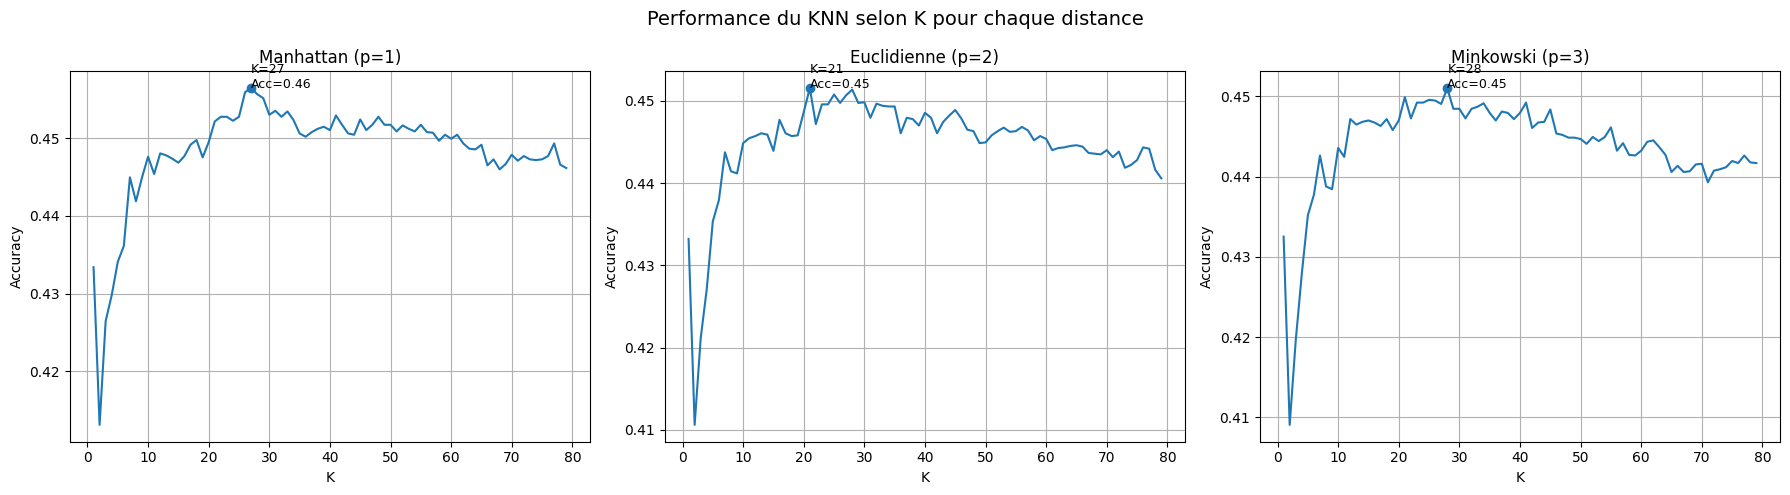

In [6]:
valeurs_k = range(1, 80)

valeurs_p = {
    1: 'Manhattan (p=1)',
    2: 'Euclidienne (p=2)',
    3: 'Minkowski (p=3)'
}

resultats_scores = {1: [], 2: [], 3: []}

meilleur_k = 0
meilleur_p = 0
meilleur_score = 0

for p in valeurs_p.keys():
    for k in valeurs_k:
        knn_temp = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=p)
        knn_temp.fit(X_train_scaled, y_train)
        score = accuracy_score(y_test, knn_temp.predict(X_test_scaled))

        resultats_scores[p].append(score)

        if score > meilleur_score:
            meilleur_score = score
            meilleur_k = k
            meilleur_p = p



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, p in enumerate(valeurs_p.keys()):
    ax = axes[idx]

    ax.plot(valeurs_k, resultats_scores[p])

    # Trouver le meilleur K pour cette distance
    scores_p = resultats_scores[p]
    best_score_p = max(scores_p)
    best_k_p = valeurs_k[scores_p.index(best_score_p)]

    # Marquer le meilleur point
    ax.scatter(best_k_p, best_score_p)
    ax.set_title(valeurs_p[p])
    ax.set_xlabel("K")
    ax.set_ylabel("Accuracy")
    ax.grid(True)

    # Annotation
    ax.text(
        best_k_p,
        best_score_p,
        f"K={best_k_p}\nAcc={best_score_p:.2f}",
        fontsize=9
    )

plt.suptitle("Performance du KNN selon K pour chaque distance", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=meilleur_k, metric='minkowski', p=meilleur_p)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.4564212328767123
              precision    recall  f1-score   support

  Après-midi       0.42      0.41      0.41      2741
       Matin       0.43      0.48      0.45      3197
        Nuit       0.52      0.47      0.49      2578
        Soir       0.48      0.47      0.47      3164

    accuracy                           0.46     11680
   macro avg       0.46      0.46      0.46     11680
weighted avg       0.46      0.46      0.46     11680



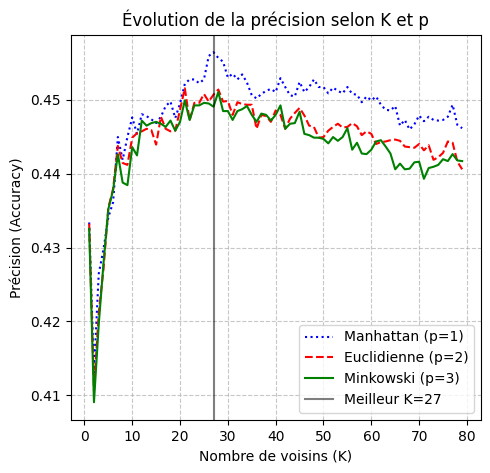

In [ ]:
fig = plt.figure(figsize=(18, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(valeurs_k, resultats_scores[1], label=valeurs_p[1], color='blue', linestyle='dotted')
ax1.plot(valeurs_k, resultats_scores[2], label=valeurs_p[2], color='red', linestyle='dashed')
ax1.plot(valeurs_k, resultats_scores[3], label=valeurs_p[3], color='green', linestyle='solid')

ax1.axvline(x=meilleur_k, color='black', linestyle='-', alpha=0.5, label=f'Meilleur K={meilleur_k}')
ax1.set_title("Évolution de la précision selon K et p")
ax1.set_xlabel("Nombre de voisins (K)")
ax1.set_ylabel("Précision (Accuracy)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)


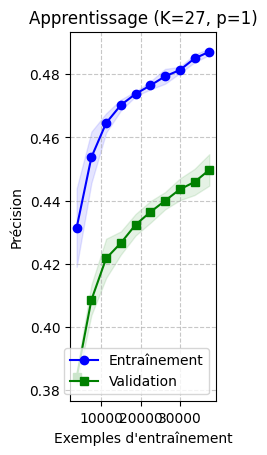

In [ ]:
ax2 = plt.subplot(1, 3, 2)
train_sizes, train_scores, test_scores = learning_curve(
    knn_final, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

ax2.plot(train_sizes, train_mean, label='Entraînement', color='blue', marker='o')
ax2.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.1)
ax2.plot(train_sizes, test_mean, label='Validation', color='green', marker='s')
ax2.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='green', alpha=0.1)
ax2.set_title(f"Apprentissage (K={meilleur_k}, p={meilleur_p})")
ax2.set_xlabel("Exemples d'entraînement")
ax2.set_ylabel("Précision")
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.7)


### **Interprétation**
L'évaluation du score de précision (46 %) s'interprète par rapport à la probabilité d'une prédiction aléatoire sur 4 classes équilibrées (25 %). Ce gain d'information (+16 %) confirme l'existence d'une corrélation mesurable entre le comportement réseau et la période de la journée.

L'analyse de ces résultats met par ailleurs en évidence une caractéristique intrinsèque du jeu de données : le chevauchement naturel des comportements (Class Overlap).

On observe en effet que de nombreuses sessions partagent des signatures volumétriques identiques quelle que soit la plage horaire. Par exemple, des processus comme les micro-requêtes en arrière-plan (ex. 0,5 Mo pour une synchronisation) présentent des caractéristiques strictement similaires qu'elles surviennent le matin, l'après-midi ou la nuit.

Géométriquement, cela se traduit par une superposition des données dans l'espace des variables : des sessions appartenant à des classes temporelles différentes partagent des coordonnées très proches. Le modèle cartographie ainsi fidèlement la réalité de ce trafic, illustrant le fait qu'une grande part des habitudes de consommation n'est pas exclusive à une période spécifique de la journée

/tmp/ipykernel_996/3086498418.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(


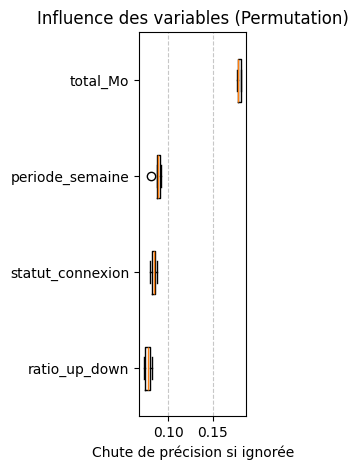

In [ ]:
ax3 = plt.subplot(1, 3, 3)
result = permutation_importance(knn_final, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

ax3.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(features)[sorted_idx]
)
ax3.set_title("Influence des variables (Permutation)")
ax3.set_xlabel("Chute de précision si ignorée")
ax3.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Difficultés rencontrées

### 1. **Faible séparabilité des classes**

La principale difficulté rencontrée dans ce projet est liée à la structure même des données. Les différentes périodes de la journée ne présentent pas des profils de consommation suffisamment distincts.

Les distributions de consommation se chevauchent fortement entre les classes, ce qui rend la classification difficile. Par exemple, une consommation modérée peut correspondre aussi bien à une activité matinale qu’à une activité en soirée.

Ce manque de séparabilité limite intrinsèquement la performance maximale du modèle, indépendamment de l’algorithme utilisé.

### 2. **Sensibilité du modèle KNN au bruit**

Le modèle KNN repose sur une hypothèse locale : les observations proches dans l’espace des variables appartiennent à la même classe.

Or, dans notre dataset, les données sont relativement bruitées et peu structurées. Cela se traduit par une instabilité des prédictions lorsque le nombre de voisins (K) est faible.

Pour pallier ce problème, il a été nécessaire d’augmenter significativement la valeur de K (jusqu’à 27), ce qui permet de lisser les décisions en considérant un voisinage plus large.

### 3. **Choix de la métrique de distance**

Le choix de la distance a un impact direct sur les performances du modèle KNN.

Nous avons testé plusieurs distances (Manhattan, Euclidienne, Minkowski) et observé que la distance de Manhattan (p=1) était la plus performante.

Cela s’explique par le fait que les variables utilisées présentent des distributions hétérogènes et ne suivent pas nécessairement une géométrie euclidienne. La distance de Manhattan est plus robuste dans ce type de contexte.
### 4. **Influence de l’échelle des variables**

Le KNN est fortement dépendant de l’échelle des variables. Sans normalisation, les variables ayant les plus grandes amplitudes dominent la distance, ce qui biaise le modèle.

Dans notre cas, les variables de consommation (en Mo) ont des ordres de grandeur très différents des variables binaires ou catégorielles.

L’application d’une normalisation (StandardScaler) a été essentielle pour garantir un comportement cohérent du modèle.
### 5. **Data leakage potentiel**

Une difficulté importante a été d’identifier et d’éliminer les variables pouvant introduire un biais d’apprentissage.

La variable `heure` permettait de déduire directement la période de la journée, conduisant à des performances artificiellement élevées.

Sa suppression a été nécessaire pour garantir que le modèle apprenne réellement des patterns comportementaux et non une correspondance directe.
### 6. **Limites liées aux données**

Les performances du modèle (≈ 41% de précision) peuvent sembler modestes, mais elles doivent être interprétées dans le contexte du problème.

Avec 4 classes, une prédiction aléatoire donnerait 25% de précision. Le modèle capture donc une partie du signal, mais reste limité par :

- la variabilité des comportements utilisateurs
- le chevauchement des distributions
- l’absence de variables fortement discriminantes

Ces limitations ne sont pas liées au modèle KNN en lui-même, mais à la nature des données disponibles.
